In [1]:
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting
import tod.dimension_reduction_classic

connected to port: 61804


In [2]:
import plotly.express as px
import plotly.graph_objects as go

treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_French-Sequoia"
grew_pattern = "pattern{X[upos<>PUNCT]}"
patterns_text_file = "../3. probability_matrix/patterns_all_nodes.txt"
analysed_category = "all_nodes"

In [3]:
corpus = tod.corpus.Corpus(
    treebank_path=treebank_path,
    grew_pattern=grew_pattern,
    patterns_text_file=patterns_text_file,
    matrix_type="coverage",
    min_occurrences=10,
)

Number of matches after filtering: 46456


In [4]:
dim_red = tod.dimension_reduction_classic.Tsne_corpus(corpus, n_components=2)
clustering = tod.clustering.HierarchicalClustering(corpus)
fig = tod.plotting.cluster_scatter_plot(corpus, dim_red, clustering)

In [5]:
fig

/opt/homebrew/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [60]:
fig.write_html("first_clustering_sequoia_tod.html")

In [6]:
cluster_assignments = {}
for i in range(1, 12):
    cluster = clustering.cluster2lexunit(i)
    for lexunit in cluster:
        cluster_assignments[lexunit] = i
cluster_assignments

{('Aclasta', 'PROPN'): 1,
 ('Angiox', 'PROPN'): 1,
 ('afin', 'ADV'): 1,
 ('ailleurs', 'ADV'): 1,
 ('ainsi', 'ADV'): 1,
 ('alors', 'ADV'): 1,
 ("aujourd'hui", 'ADV'): 1,
 ('aussi', 'ADV'): 1,
 ('avoir', 'AUX'): 1,
 ('bien', 'ADV'): 1,
 ('car', 'CCONJ'): 1,
 ('ce', 'PRON'): 1,
 ('ceci', 'PRON'): 1,
 ('cela', 'PRON'): 1,
 ('celui-ci', 'PRON'): 1,
 ('cependant', 'ADV'): 1,
 ('comme', 'SCONJ'): 1,
 ('comment', 'ADV'): 1,
 ('donc', 'ADV'): 1,
 ('dont', 'PRON'): 1,
 ('déjà', 'ADV'): 1,
 ('en', 'PRON'): 1,
 ('encore', 'ADV'): 1,
 ('et', 'CCONJ'): 1,
 ('eux', 'PRON'): 1,
 ('faire', 'AUX'): 1,
 ('finalement', 'ADV'): 1,
 ('immédiatement', 'ADV'): 1,
 ('jamais', 'ADV'): 1,
 ('lequel', 'PRON'): 1,
 ('lorsque', 'SCONJ'): 1,
 ('lui', 'PRON'): 1,
 ('là', 'ADV'): 1,
 ('maintenant', 'ADV'): 1,
 ('mais', 'CCONJ'): 1,
 ('moi', 'PRON'): 1,
 ('moins', 'ADV'): 1,
 ('même', 'ADV'): 1,
 ('ne', 'ADV'): 1,
 ('ni', 'CCONJ'): 1,
 ('non', 'ADV'): 1,
 ('notamment', 'ADV'): 1,
 ('nous', 'PRON'): 1,
 ('on', 'PRON'): 

In [63]:
cluster_assignments[('trouver', 'VERB')]

6

In [62]:
import importlib
importlib.reload(tod.corpus)
patterns_text_file_with_lemmas = "patterns_all_nodes_with_lemmas.txt"
it_corpus = tod.corpus.IterativeCorpus(
    clusters = cluster_assignments,
    treebank_path=treebank_path,
    grew_pattern=grew_pattern,
    patterns_text_file=patterns_text_file_with_lemmas,
    matrix_type="coverage",
    min_occurrences=10,
)

Number of matches after filtering: 46456


In [64]:
dim_red = tod.dimension_reduction_classic.Tsne_corpus(it_corpus, n_components=2)
clustering = tod.clustering.HierarchicalClustering(it_corpus)
fig = tod.plotting.cluster_scatter_plot(it_corpus, dim_red, clustering)

In [65]:
fig

In [66]:
fig.write_html("iterative_Clust_sequoia_tod.html")

In [67]:
import importlib
importlib.reload(tod.corpus)
patterns_text_file_with_lemmas = "patterns_all_nodes_with_lemmas.txt"
it_corpus_no_pos = tod.corpus.IterativeCorpusNoPos(
    clusters = cluster_assignments,
    treebank_path=treebank_path,
    grew_pattern=grew_pattern,
    patterns_text_file=patterns_text_file_with_lemmas,
    matrix_type="coverage",
    min_occurrences=10,
)

Number of matches after filtering: 46456


In [68]:
dim_red = tod.dimension_reduction_classic.Tsne_corpus(it_corpus_no_pos, n_components=2)
clustering = tod.clustering.HierarchicalClustering(it_corpus_no_pos)
fig = tod.plotting.cluster_scatter_plot(it_corpus_no_pos, dim_red, clustering)

In [69]:
fig

In [70]:
fig.write_html("iterative_clust_nopos_sequoia_tod.html")

In [74]:
import numpy as np

np.save("coverage_feature_matrix_sequoia_tod.npy", corpus.feature_matrix)

In [8]:
import numpy as np
X = np.load("coverage_feature_matrix_sequoia_tod.npy")


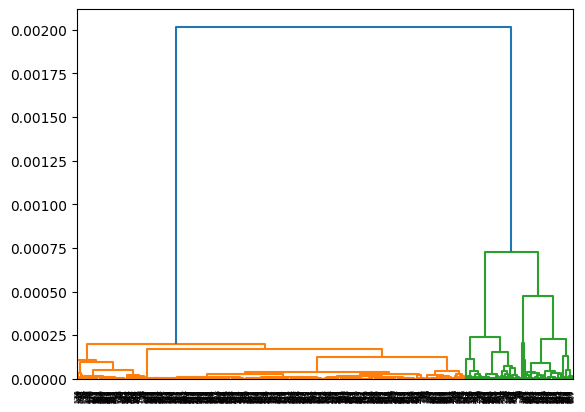

In [77]:
import matplotlib.pyplot as plt
import pysparcl

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage


# X is a numpy array of (samples, features) shape.
perm = pysparcl.hierarchy.permute(X)
result = pysparcl.hierarchy.pdist(X, wbound=perm['bestw'])
link = linkage(result['u'], method='average')
dendro = dendrogram(link)
plt.show()

In [91]:
important_feature_index = np.where(result['w'] != 0)
print(important_feature_index)


(array([298, 299, 305]),)


In [98]:
for i in important_feature_index:
    for j in i:
        print(corpus.idx2feature(j))
    

node:X:parent:position=after
node:X:parent:position=before
node:X:parent:upos=NOUN


In [99]:
result.keys()

dict_keys(['u', 'w', 'crit', 'dists'])

In [104]:
result['dists'].shape

(259560, 369)

In [ ]:
import matplotlib.pyplot as plt
import pysparcl

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage


# X is a numpy array of (samples, features) shape.
k_perm = pysparcl.cluster.permute(X, k=7)
kmeans_result = pysparcl.cluster.kmeans(X, k=7)


In [110]:
kmeans_result[0].keys()

dict_keys(['ws', 'cs', 'bcss_ws', 'wbound'])

In [118]:
len(kmeans_result[0]['cs'])

721

In [119]:
for i in range(len(kmeans_result[0]['cs'])):
    print(corpus.idx2lexunit(i), kmeans_result[0]['cs'][i])

('%', 'NOUN') 3
('/', 'ADP') 0
('/', 'SYM') 6
('1', 'NUM') 6
('10', 'NUM') 5
('100', 'NUM') 0
('11', 'NUM') 3
('12', 'NUM') 5
('13', 'NUM') 6
('14', 'NUM') 6
('15', 'NUM') 5
('16', 'NUM') 6
('17', 'NUM') 5
('18', 'NUM') 5
('1989', 'NUM') 2
('1991', 'NUM') 2
('1994', 'NUM') 2
('1995', 'NUM') 2
('1998', 'NUM') 4
('1999', 'NUM') 2
('2', 'NUM') 5
('20', 'NUM') 5
('2000', 'NUM') 2
('2001', 'NUM') 2
('2002', 'NUM') 2
('2004', 'NUM') 2
('2005', 'NUM') 2
('2006', 'NUM') 2
('21', 'NUM') 5
('22', 'NUM') 3
('24', 'NUM') 5
('25', 'NUM') 6
('3', 'NUM') 5
('30', 'NUM') 0
('3e', 'ADJ') 5
('4', 'NUM') 5
('5', 'NUM') 5
('500', 'NUM') 0
('6', 'NUM') 5
('7', 'NUM') 6
('8', 'NUM') 5
('9', 'NUM') 5
('ACT', 'NOUN') 3
('ACUITY', 'PROPN') 2
('Aclasta', 'PROPN') 6
('Alain', 'PROPN') 3
('Alfred', 'PROPN') 3
('Andrew', 'PROPN') 4
('Angiox', 'PROPN') 6
('B', 'NOUN') 2
('Christine', 'PROPN') 4
('D', 'NOUN') 2
('Didier', 'PROPN') 6
('Elf', 'PROPN') 2
('Europe', 'PROPN') 3
('France', 'PROPN') 3
('Francis', 'PROPN') 

In [142]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Since kmeans_result is a list of results for different wbounds,
# let's use the best result (you can also choose a specific index)
best_result_idx = 6 # or choose based on some criteria
cluster_assignments = kmeans_result[best_result_idx]['cs']

# Extract the data
lexical_units = []
cluster_labels = []

for i in range(len(cluster_assignments)):
    lexical_units.append(str(corpus.idx2lexunit(i)))
    cluster_labels.append(cluster_assignments[i])

# Apply t-sne for visualization
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
coords = tsne.fit_transform(X)
x_coords = coords[:, 0]
y_coords = coords[:, 1]
x_label = 't-SNE Dimension 1'
y_label = 't-SNE Dimension 2'

# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# coords = pca.fit_transform(X)
# x_coords = coords[:, 0]
# y_coords = coords[:, 1]
# x_label = f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)'
# y_label = f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)'

# Create DataFrame
df = pd.DataFrame({
    'x': x_coords,
    'y': y_coords,
    'lexical_unit': lexical_units,
    'cluster': cluster_labels
})

# Create scatter plot with discrete colors for clusters
fig = px.scatter(
    df, 
    x='x', 
    y='y', 
    color='cluster',
    hover_name='lexical_unit',
    title=f'Sparse K-means Clustering Results (wbound={kmeans_result[best_result_idx]["wbound"]:.3f})',
    labels={'cluster': 'Cluster ID', 'x': x_label, 'y': y_label},
    color_discrete_sequence=px.colors.qualitative.Set1
)

# Update markers
fig.update_traces(marker=dict(size=8, line=dict(width=1, color='white')))

# Update layout
fig.update_layout(
    width=900,
    height=700,
    showlegend=True
)

fig.show()

In [129]:
# Compare different wbound results
import plotly.subplots as sp

n_results = min(10, len(kmeans_result))  # Show up to 4 results
fig = sp.make_subplots(
    rows=5, cols=2,
    subplot_titles=[f'wbound={res["wbound"]:.3f}' for res in kmeans_result[:n_results]]
)

for idx in range(n_results):
    cluster_assignments = kmeans_result[idx]['cs']
    
    row = idx // 2 + 1
    col = idx % 2 + 1
    
    fig.add_trace(
        go.Scatter(
            x=x_coords,
            y=y_coords,
            mode='markers',
            marker=dict(
                color=cluster_assignments,
                colorscale='viridis',
                size=6
            ),
            text=lexical_units,
            hovertemplate='<b>%{text}</b><br>Cluster: %{marker.color}<extra></extra>',
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    height=800,
    title_text="Sparse K-means Results for Different wbound Values"
)
fig.show()

In [131]:
# Show feature importance for the best result
best_weights = kmeans_result[best_result_idx]['ws']
important_features = np.where(best_weights > 0.01)[0]  # Adjust threshold as needed

print(f"Most important features (weights > 0.01):")
for feat_idx in important_features:
    print(f"Feature {feat_idx}: {corpus.idx2feature(feat_idx)} (weight:{best_weights[feat_idx]:.4f})")

Most important features (weights > 0.01):
Feature 298: node:X:parent:position=after (weight:0.9944)
Feature 305: node:X:parent:upos=NOUN (weight:0.1056)


In [127]:
# Find the best wbound based on your permutation test
print(f"Recommended wbound from permutation test: {k_perm['bestw']:.3f}")

# Use this for your final clustering
best_wbound_idx = np.argmin(np.abs([res['wbound'] for res in kmeans_result] - k_perm['bestw']))
print(f"Using result index {best_wbound_idx} with wbound={kmeans_result[best_wbound_idx]['wbound']:.3f}")

Recommended wbound from permutation test: 7.105
Using result index 6 with wbound=6.819


In [132]:
# This shows you the trade-off between sparsity and cluster quality
for i, result in enumerate(kmeans_result[:5]):
    n_features_used = np.sum(result['ws'] > 0.01)
    total_features = len(result['ws'])
    sparsity = (total_features - n_features_used) / total_features * 100
    
    print(f"wbound={result['wbound']:.2f}: {sparsity:.1f}% sparse, using {n_features_used} features")

wbound=1.10: 99.5% sparse, using 2 features
wbound=2.05: 98.6% sparse, using 5 features
wbound=3.01: 94.6% sparse, using 20 features
wbound=3.96: 90.5% sparse, using 35 features
wbound=4.91: 87.5% sparse, using 46 features


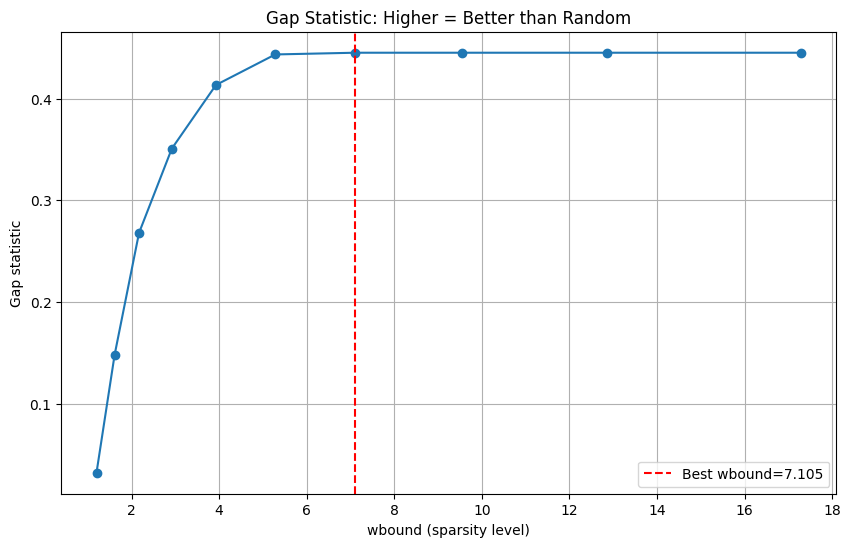

In [133]:
# Plot the gap statistic to understand why bestw was chosen
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_perm['wbounds'], k_perm['gaps'], 'o-')
plt.axvline(k_perm['bestw'], color='red', linestyle='--', label=f'Best wbound={k_perm["bestw"]:.3f}')
plt.xlabel('wbound (sparsity level)')
plt.ylabel('Gap statistic')
plt.title('Gap Statistic: Higher = Better than Random')
plt.legend()
plt.grid(True)
plt.show()

In [134]:
# Get the best result weights
best_weights = kmeans_result[best_result_idx]['ws']

# Create a list of (feature_index, feature_name, weight) tuples
feature_importance = []
for feat_idx in range(len(best_weights)):
    feature_name = corpus.idx2feature(feat_idx)
    weight = best_weights[feat_idx]
    feature_importance.append((feat_idx, feature_name, weight))

# Sort by weight (importance) in descending order
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[2], reverse=True)

# Display all features ranked by importance
print(f"All {len(feature_importance_sorted)} features ranked by importance:")
print("=" * 80)
for rank, (feat_idx, feature_name, weight) in enumerate(feature_importance_sorted, 1):
    print(f"{rank:3d}. {feature_name:<50} weight: {weight:.6f}")

All 369 features ranked by importance:
  1. node:X:parent:position=after                       weight: 0.994411
  2. node:X:parent:upos=NOUN                            weight: 0.105580
  3. node:X:child:Definite=Def                          weight: 0.000000
  4. node:X:child:Definite=Ind                          weight: 0.000000
  5. node:X:child:ExtPos=ADJ                            weight: 0.000000
  6. node:X:child:ExtPos=ADP                            weight: 0.000000
  7. node:X:child:ExtPos=ADV                            weight: 0.000000
  8. node:X:child:ExtPos=CCONJ                          weight: 0.000000
  9. node:X:child:ExtPos=DET                            weight: 0.000000
 10. node:X:child:ExtPos=PRON                           weight: 0.000000
 11. node:X:child:ExtPos=PROPN                          weight: 0.000000
 12. node:X:child:ExtPos=SCONJ                          weight: 0.000000
 13. node:X:child:Gender=Fem                            weight: 0.000000
 14. node:X:

In [135]:
# Check the actual distribution of weights
print(f"Total features: {len(best_weights)}")
print(f"Non-zero weights: {np.count_nonzero(best_weights)}")
print(f"Max weight: {best_weights.max():.6f}")
print(f"Min weight: {best_weights.min():.6f}")
print(f"Mean weight: {best_weights.mean():.6f}")

# Check if this is consistent across different wbound values
print("\nWeight statistics across different wbounds:")
for i, result in enumerate(kmeans_result[:5]):
    weights = result['ws']
    non_zero = np.count_nonzero(weights)
    print(f"wbound={result['wbound']:.2f}: {non_zero} non-zero weights, max={weights.max():.6f}")

Total features: 369
Non-zero weights: 2
Max weight: 0.994411
Min weight: 0.000000
Mean weight: 0.002981

Weight statistics across different wbounds:
wbound=1.10: 2 non-zero weights, max=0.994411
wbound=2.05: 5 non-zero weights, max=0.669819
wbound=3.01: 20 non-zero weights, max=0.587747
wbound=3.96: 37 non-zero weights, max=0.539841
wbound=4.91: 72 non-zero weights, max=0.495986


In [136]:
# Make sure you're using the right result index
print(f"Current best_result_idx: {best_result_idx}")
print(f"Recommended wbound from permutation: {k_perm['bestw']:.3f}")
print(f"Current wbound being used: {kmeans_result[best_result_idx]['wbound']:.3f}")

# Use the recommended wbound instead
best_wbound_idx = np.argmin(np.abs([res['wbound'] for res in kmeans_result] - k_perm['bestw']))
print(f"Should use index: {best_wbound_idx} with wbound={kmeans_result[best_wbound_idx]['wbound']:.3f}")

Current best_result_idx: 0
Recommended wbound from permutation: 7.105
Current wbound being used: 1.100
Should use index: 6 with wbound=6.819


In [137]:
# Check if your feature matrix has the right properties
print(f"Feature matrix shape: {X.shape}")
print(f"Feature matrix range: {X.min():.6f} to {X.max():.6f}")
print(f"Feature matrix mean: {X.mean():.6f}")
print(f"Any NaN values: {np.isnan(X).any()}")
print(f"Any infinite values: {np.isinf(X).any()}")

Feature matrix shape: (721, 369)
Feature matrix range: 0.000000 to 0.181818
Feature matrix mean: 0.002710
Any NaN values: False
Any infinite values: False


In [138]:
# Use the correct best result
best_result_idx = best_wbound_idx  # Update this line
best_weights = kmeans_result[best_result_idx]['ws']

print(f"Using recommended wbound {kmeans_result[best_result_idx]['wbound']:.3f}:")
print(f"Non-zero weights: {np.count_nonzero(best_weights)}")
print(f"Weights > 0.001: {np.sum(best_weights > 0.001)}")

Using recommended wbound 6.819:
Non-zero weights: 369
Weights > 0.001: 151


In [140]:
# Update the feature importance analysis with the correct weights
best_result_idx = best_wbound_idx  # This should now be index 6
best_weights = kmeans_result[best_result_idx]['ws']

# Create a list of (feature_index, feature_name, weight) tuples
feature_importance = []
for feat_idx in range(len(best_weights)):
    feature_name = corpus.idx2feature(feat_idx)
    weight = best_weights[feat_idx]
    feature_importance.append((feat_idx, feature_name, weight))

# Sort by weight (importance) in descending order
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[2], reverse=True)

# Show top 20 most important features
print(f"Top 20 most important features (using recommended wbound={kmeans_result[best_result_idx]['wbound']:.3f}):")
print("=" * 80)
for rank, (feat_idx, feature_name, weight) in enumerate(feature_importance_sorted[:20], 1):
    print(f"{rank:2d}. {feature_name:<50} weight: {weight:.6f}")

Top 20 most important features (using recommended wbound=6.819):
 1. node:X:parent:position=after                       weight: 0.475340
 2. node:X:parent:upos=NOUN                            weight: 0.419145
 3. node:X:parent:position=before                      weight: 0.310860
 4. node:X:prev:upos=NOUN                              weight: 0.287482
 5. node:X:own:rel_shallow=amod                        weight: 0.246710
 6. node:X:child:rel_shallow=det                       weight: 0.178765
 7. node:X:child:upos=DET                              weight: 0.177763
 8. node:X:next:upos=NOUN                              weight: 0.172073
 9. node:X:prev:upos=DET                               weight: 0.153225
10. node:X:child:rel_shallow=case                      weight: 0.144186
11. node:X:child:PronType=Art                          weight: 0.138868
12. node:X:child:upos=ADP                              weight: 0.132994
13. node:X:child:Number=Sing                           weight: 0.120896

#  Sparse k-means (tidy implementation)

In [10]:
import pysparcl
k = 7
tidy_k_perm = pysparcl.cluster.permute(X, k=k, nperms=25, nvals=10)

print("Best wbound:", tidy_k_perm['bestw'])

Best wbound: 7.1050020956713045


In [11]:
tidy_k_result = pysparcl.cluster.kmeans(X, k=k, wbounds=tidy_k_perm['bestw'])[0]
tidy_k_weights = tidy_k_result['ws']

In [12]:
tidy_k_clusters = {i: [] for i in range(k)}
for i in range(len(tidy_k_result['cs'])):
    cluster_id = tidy_k_result['cs'][i]
    tidy_k_clusters[cluster_id].append(corpus.idx2lexunit(i))

In [14]:
from sklearn.manifold import TSNE
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
# Create a DataFrame for Plotly
df = pd.DataFrame({
    'PCA1': X_tsne[:, 0],
    'PCA2': X_tsne[:, 1],
    'Cluster': tidy_k_result['cs'],
    'Word': [corpus.idx2lexunit(i) for i in range(len(tidy_k_result['cs']))]
})
fig = go.Figure()
for cluster in range(k):
    cluster_data = df[df['Cluster'] == cluster]
    fig.add_trace(go.Scatter(
        x=cluster_data['PCA1'],
        y=cluster_data['PCA2'],
        mode='markers',
        marker=dict(size=10),
        name=f'Cluster {cluster}',
        text=cluster_data['Word'],
        hovertemplate='%{text}<extra></extra>',
    ))

fig.update_layout(
    title='Word Clusters',
    xaxis_title='tsne1',
    yaxis_title='tsne2',
    width=1600,  # Set the width of the figure
    height=800,  # Set the height of the figure

    updatemenus=[
        {
            'buttons': [
                {
                    'label': 'All Clusters',
                    'method': 'update',
                    'args': [{'visible': [True] * k},
                             {'title': 'All Clusters'}]
                }
            ] + [
                {
                    'label': f'Cluster {i}',
                    'method': 'update',
                    'args': [{'visible': [j == i - 1 for j in range(k)]},
                             {'title': f'Cluster {i}'}]
                } for i in range(1, k + 1)
            ],
            'direction': 'down',
            'showactive': True
        }
    ]
)

fig.show()

In [15]:
tidy_k_important_features = np.argsort(-tidy_k_weights) 
for i in tidy_k_important_features[:10]:  
    print(f"{corpus.idx2feature(i)}: weight {tidy_k_weights[i]:.3f}")


node:X:parent:position=after: weight 0.470
node:X:parent:upos=NOUN: weight 0.399
node:X:parent:position=before: weight 0.307
node:X:prev:upos=NOUN: weight 0.296
node:X:own:rel_shallow=amod: weight 0.236
node:X:next:upos=NOUN: weight 0.203
node:X:child:rel_shallow=det: weight 0.177
node:X:child:upos=DET: weight 0.176
node:X:prev:upos=DET: weight 0.146
node:X:child:PronType=Art: weight 0.138


# Sparse hierarchical clustering (tidy implementation)

In [167]:
tidy_hierarchical_perm = pysparcl.hierarchy.permute(X)
print("Best wbound:", tidy_hierarchical_perm['bestw'])

Best wbound: 1.1


In [168]:
tidy_hierarchical_result = pysparcl.hierarchy.pdist(X, wbound=tidy_hierarchical_perm['bestw'])
dists = tidy_hierarchical_result['dists']

In [16]:
tidy_hierarchical_result.keys()

NameError: name 'tidy_hierarchical_result' is not defined

In [169]:

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt


linked = linkage(
            dists, method="average", optimal_ordering=True
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Complete linkage', fontsize=12) 
plt.xlabel('Sample index', fontsize=12)  
plt.ylabel('Distance', fontsize=12)  
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.show()

: 

: 

In [ ]:
important_features = np.argsort(-weights)
for i in important_features[:10]:
    print(f"Feature {i}: weight {weights[i]:.3f}")